In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    StackingRegressor,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


### 1.1 Load and clean the dataset

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.drop(columns=['Order_ID'], inplace=True)

for col in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Courier_Experience_yrs']:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [4]:
df = pd.get_dummies(
    df,
    columns=['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'],
    drop_first=True,
    dtype=int
)
print(f'Shape after encoding: {df.shape}')
print('Columns:', df.columns.tolist())

Shape after encoding: (1000, 15)
Columns: ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy', 'Traffic_Level_Low', 'Traffic_Level_Medium', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter']


### 1.2 Reproduce train/test split 

In [5]:
TARGET = 'Delivery_Time_min'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f'Train size: {X_train.shape}  |  Test size: {X_test.shape}')
FEATURE_NAMES = X.columns.tolist()

Train size: (700, 14)  |  Test size: (300, 14)


### 1.3 Re-train baseline models

In [6]:
def evaluate(name, y_true, y_pred):
    """Return a dict of metrics and print a formatted summary."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'\n{name}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:.4f}')
    return {'Model': name, 'Features': 'original', 'RMSE': rmse, 'R²': r2, 'MAE': mae}

In [7]:
# Linear Regression
lr_base = LinearRegression()
lr_base.fit(X_train, y_train)
y_pred_lr_base = lr_base.predict(X_test)
row_lr_base = evaluate('Linear Regression', y_test, y_pred_lr_base)


Linear Regression
  RMSE : 9.1639
  R²   : 0.8323
  MAE  : 6.0157


In [8]:
# Random Forest
rf_base = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_base.fit(X_train, y_train)
y_pred_rf_base = rf_base.predict(X_test)
row_rf_base = evaluate('Random Forest', y_test, y_pred_rf_base)


Random Forest
  RMSE : 10.1535
  R²   : 0.7941
  MAE  : 6.9024


### 2.1 Ensemble #1 — Extra Trees Regressor

In [9]:
et = ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
row_et = evaluate('Extra Trees (Bagging family)', y_test, y_pred_et)
row_et['Model'] = 'Extra Trees'


Extra Trees (Bagging family)
  RMSE : 10.5384
  R²   : 0.7782
  MAE  : 7.0784


### 2.2 Ensemble #2 — Gradient Boosting Regressor

In [10]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
row_gb = evaluate('Gradient Boosting (Boosting family)', y_test, y_pred_gb)
row_gb['Model'] = 'Gradient Boosting'


Gradient Boosting (Boosting family)
  RMSE : 9.7367
  R²   : 0.8107
  MAE  : 6.5042


In [11]:
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),
    n_estimators=200,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
row_ada = evaluate('AdaBoost (Boosting family)', y_test, y_pred_ada)
row_ada['Model'] = 'AdaBoost'


AdaBoost (Boosting family)
  RMSE : 15.3538
  R²   : 0.5292
  MAE  : 12.2644


### 2.3 Feature importances (Gradient Boosting)

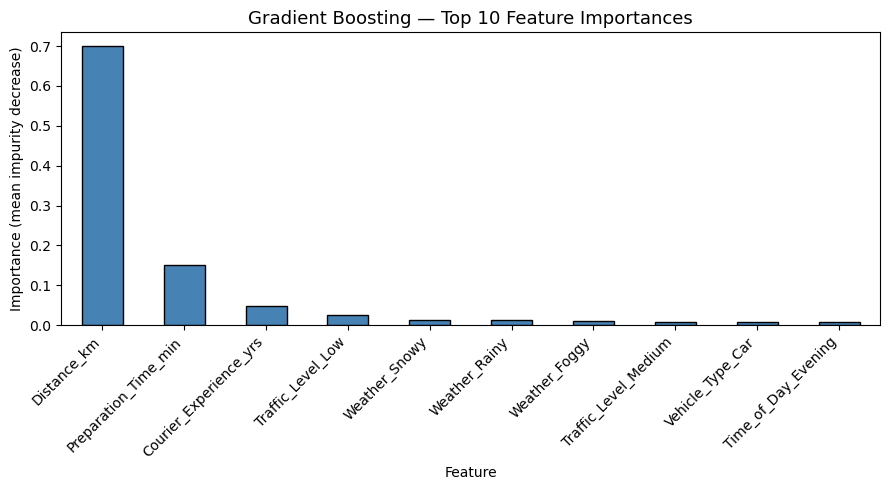


Top 5 features:
Distance_km               0.699557
Preparation_Time_min      0.151743
Courier_Experience_yrs    0.047356
Traffic_Level_Low         0.025123
Weather_Snowy             0.014051


In [12]:
importances = pd.Series(gb.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importances.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Gradient Boosting — Top 10 Feature Importances', fontsize=13)
ax.set_ylabel('Importance (mean impurity decrease)')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importances_gb.png', dpi=120)
plt.show()

print('\nTop 5 features:')
print(importances.head(5).to_string())

**Interpretation of top 5 features:**

1. **`Distance_km`** — In the Assignment 1 scatter plot, distance had the strongest linear correlation with delivery time, so it being the top predictor is expected.
2. **`Preparation_Time_min`** — Since bigger orders take more time to prepare, this is self-explanatory
3. **`Courier_Experience_yrs`** — EDA showed that more experienced couriers consistently deliver faster; the model was able to cature that.
4. **`Traffic_Level_Low`** — Lesser traffic improved the delivery time; the EDA correlation showed a slight relationship
5. **`Weather_*` dummies** — Adverse weather added scatter to delivery times; the EDA correlation heatmap showed a moderate relationship.

---
## Task 3 — Dimensionality Reduction with PCA

### 3.1 Scale features

PCA finds directions of maximum variance. If features are on different scales (e.g., `Distance_km` in the hundreds vs. a binary dummy in {0, 1}), unscaled features would allow high-magnitude features to dominate the principal components regardless of their actual informational content — so scaling is required before PCA.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only — no leakage
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test
print(f'Scaled train shape: {X_train_scaled.shape}')

Scaled train shape: (700, 14)


### 3.2 Fit PCA on training set and plot cumulative explained variance

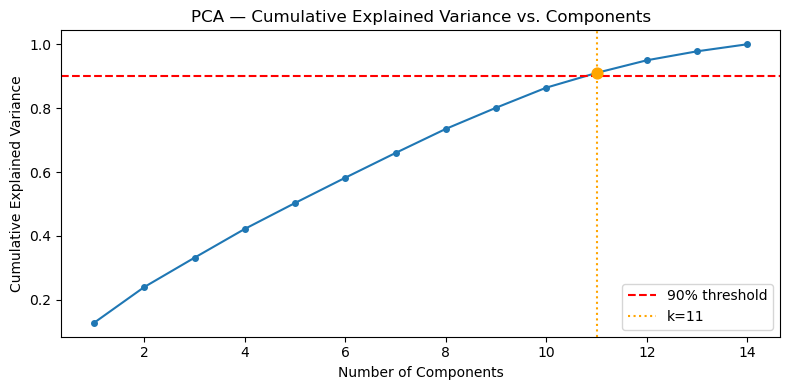


Chosen k = 11  (retains 91.0% of variance)


In [14]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)  # fit ONLY on train set to prevent data leakage

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_total = len(cumvar)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, n_components_total + 1), cumvar, marker='o', markersize=4, linewidth=1.5)
ax.axhline(0.90, color='red', linestyle='--', label='90% threshold')

# Annotate the crossing point
k90 = int(np.argmax(cumvar >= 0.90)) + 1
ax.axvline(k90, color='orange', linestyle=':', label=f'k={k90}')
ax.scatter([k90], [cumvar[k90-1]], color='orange', zorder=5, s=60)

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance vs. Components')
ax.legend()
plt.tight_layout()
plt.savefig('pca_cumvar.png', dpi=120)
plt.show()

print(f'\nChosen k = {k90}  (retains {cumvar[k90-1]*100:.1f}% of variance)')

### 3.3 Justify choice of k

We choose `k` as the smallest number of principal components that retains at least 90% of the total variance (the red dashed line in the plot above). This threshold balances dimensionality reduction — which lowers training time and reduces the risk of overfitting — against information loss: discarding too many components would remove genuine signal, not just noise.

In [15]:
# Apply PCA with the chosen k
pca = PCA(n_components=k90, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)   # fit on train only
X_test_pca  = pca.transform(X_test_scaled)

print(f'PCA-transformed shapes  —  train: {X_train_pca.shape}, test: {X_test_pca.shape}')

PCA-transformed shapes  —  train: (700, 11), test: (300, 11)


### 3.4 Re-train Linear Regression on PCA features

In [16]:
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = lr_pca.predict(X_test_pca)
row_lr_pca = evaluate(f'Linear Regression on PCA({k90})', y_test, y_pred_lr_pca)
row_lr_pca['Model'] = f'Linear Regression on PCA({k90})'
row_lr_pca['Features'] = f'PCA({k90})'


Linear Regression on PCA(11)
  RMSE : 10.4778
  R²   : 0.7807
  MAE  : 7.2078


### 3.5 Re-train best ensemble on PCA features

In [17]:
# We use Gradient Boosting (best ensemble from Task 2) on PCA-transformed features
gb_pca = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb_pca.fit(X_train_pca, y_train)
y_pred_gb_pca = gb_pca.predict(X_test_pca)
row_gb_pca = evaluate(f'Gradient Boosting on PCA({k90})', y_test, y_pred_gb_pca)
row_gb_pca['Model'] = f'Gradient Boosting on PCA({k90})'
row_gb_pca['Features'] = f'PCA({k90})'


Gradient Boosting on PCA(11)
  RMSE : 10.7941
  R²   : 0.7673
  MAE  : 7.5343


---
## Task 4 — Comparison Table and Visualization

In [18]:
results = pd.DataFrame([
    row_lr_base,
    row_rf_base,
    row_et,
    row_gb,
    row_lr_pca,
    row_gb_pca,
])

# Round for readability
results[['RMSE', 'R²', 'MAE']] = results[['RMSE', 'R²', 'MAE']].round(4)

# Identify best row per metric
best_rmse = results['RMSE'].idxmin()
best_r2   = results['R²'].idxmax()
best_mae  = results['MAE'].idxmin()

print('=== Comparison Table ===')
print(results[['Model', 'Features', 'RMSE', 'R²', 'MAE']].to_string(index=False))
print(f'\nBest RMSE : {results.loc[best_rmse, "Model"]}  ({results.loc[best_rmse, "RMSE"]})')
print(f'Best R²   : {results.loc[best_r2,   "Model"]}  ({results.loc[best_r2,   "R²"]})')
print(f'Best MAE  : {results.loc[best_mae,  "Model"]}  ({results.loc[best_mae,  "MAE"]})')

=== Comparison Table ===
                       Model Features    RMSE     R²    MAE
           Linear Regression original  9.1639 0.8323 6.0157
               Random Forest original 10.1535 0.7941 6.9024
                 Extra Trees original 10.5384 0.7782 7.0784
           Gradient Boosting original  9.7367 0.8107 6.5042
Linear Regression on PCA(11)  PCA(11) 10.4778 0.7807 7.2078
Gradient Boosting on PCA(11)  PCA(11) 10.7941 0.7673 7.5343

Best RMSE : Linear Regression  (9.1639)
Best R²   : Linear Regression  (0.8323)
Best MAE  : Linear Regression  (6.0157)


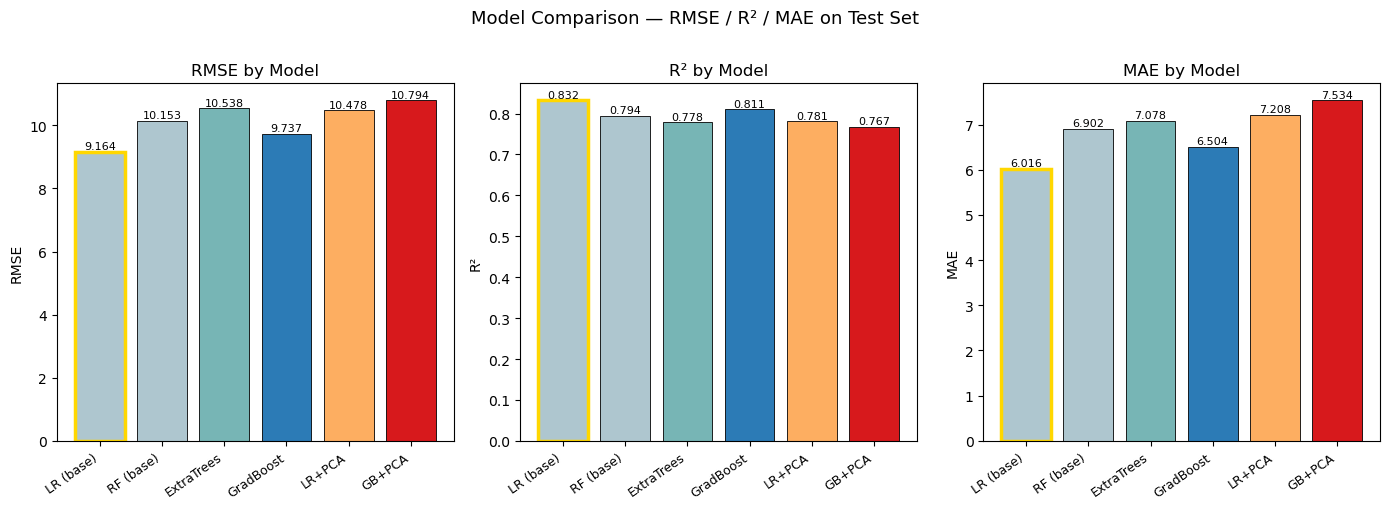

In [19]:
# Bar chart comparison of RMSE across all models
short_names = [
    'LR (base)', 'RF (base)', 'ExtraTrees', 'GradBoost',
    f'LR+PCA', f'GB+PCA'
]

colors = ['#aec6cf'] * 2 + ['#77b5b5', '#2c7bb6'] + ['#fdae61', '#d7191c']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, ascending in zip(axes, ['RMSE', 'R²', 'MAE'], [True, False, True]):
    vals = results[metric].values
    bars = ax.bar(short_names, vals, color=colors, edgecolor='black', linewidth=0.6)
    # Highlight the best bar
    best_idx = int(np.argmin(vals)) if ascending else int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.set_title(f'{metric} by Model', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=9)
    # Annotate values
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002 * max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — RMSE / R² / MAE on Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()